---
# DIABETES MULTI-CLASS DETECTION

## GROUP MEMBERS: Katriel Chiu, Nhi Nguyen, Yuxin Zhang, Daniel Cai

---

---
# TASKS
## Daniel: Data processing and cleaning
## Yuxin: Diagrams and feature engineering
## Nhi: Modeling algorithm and evaluation
## Katriel: Model visualization and hyperparameter optimization
---

In [ ]:
'LIBRARIES'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler  # for scaling
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

## Data processing and cleaning

In [ ]:
df = pd.read_csv('diabetes_dataset.csv')
df_filtered = df[
    ~df['diabetes_stage'].isin(['Type 1', 'Gestational']) #prune type 1 and gestational entries
]
print(df_filtered['diabetes_stage'].value_counts())
df_filtered.to_csv("diabetes_filtered.csv", index=False) #saves results to new csv after prune

df = pd.read_csv("diabetes_filtered.csv")

encoded_cats = [
    'family_history_diabetes',
    'hypertension_history',
    'cardiovascular_history',
    'diagnosed_diabetes'
]

for col in encoded_cats:
    df[col] = df[col].astype('category') #manually set encoded categorical columns to not be numerical

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

df.info() #general overview + shows no missing values as total number of entries = number of non null

print("Duplicate rows:", df.duplicated().sum())

df.describe(include=['int64', 'float64']).T #descriptive stats of numerical data

diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Name: count, dtype: int64
Categorical Columns:
Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'family_history_diabetes',
       'hypertension_history', 'cardiovascular_history', 'diabetes_stage',
       'diagnosed_diabetes'],
      dtype='object')

Numerical Columns:
Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'glucose_fasting', 'glucose_postprandial',
       'insulin_level', 'hba1c', 'diabetes_risk_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99600 entries, 0 to 99599
Data columns (total 31 columns):
 #   Column          

,count,mean,std,min,25%,50%,75%,max
age,99600.0,50.186968,15.593027,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,99600.0,2.003554,1.417832,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,99600.0,118.906406,84.414436,0.00,57.00,100.00,160.00,833.00
diet_score,99600.0,5.994688,1.780715,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,99600.0,6.997926,1.094681,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,99600.0,5.996369,2.468157,0.50,4.30,6.00,7.70,16.80
bmi,99600.0,25.615464,3.585877,15.00,23.20,25.60,28.00,39.20
waist_to_hip_ratio,99600.0,0.856100,0.046832,0.67,0.82,0.86,0.89,1.06
systolic_bp,99600.0,115.834187,14.282098,90.00,106.00,116.00,126.00,179.00
diastolic_bp,99600.0,75.243052,8.202624,50.00,70.00,75.00,81.00,110.00


## Diagrams and feature engineering

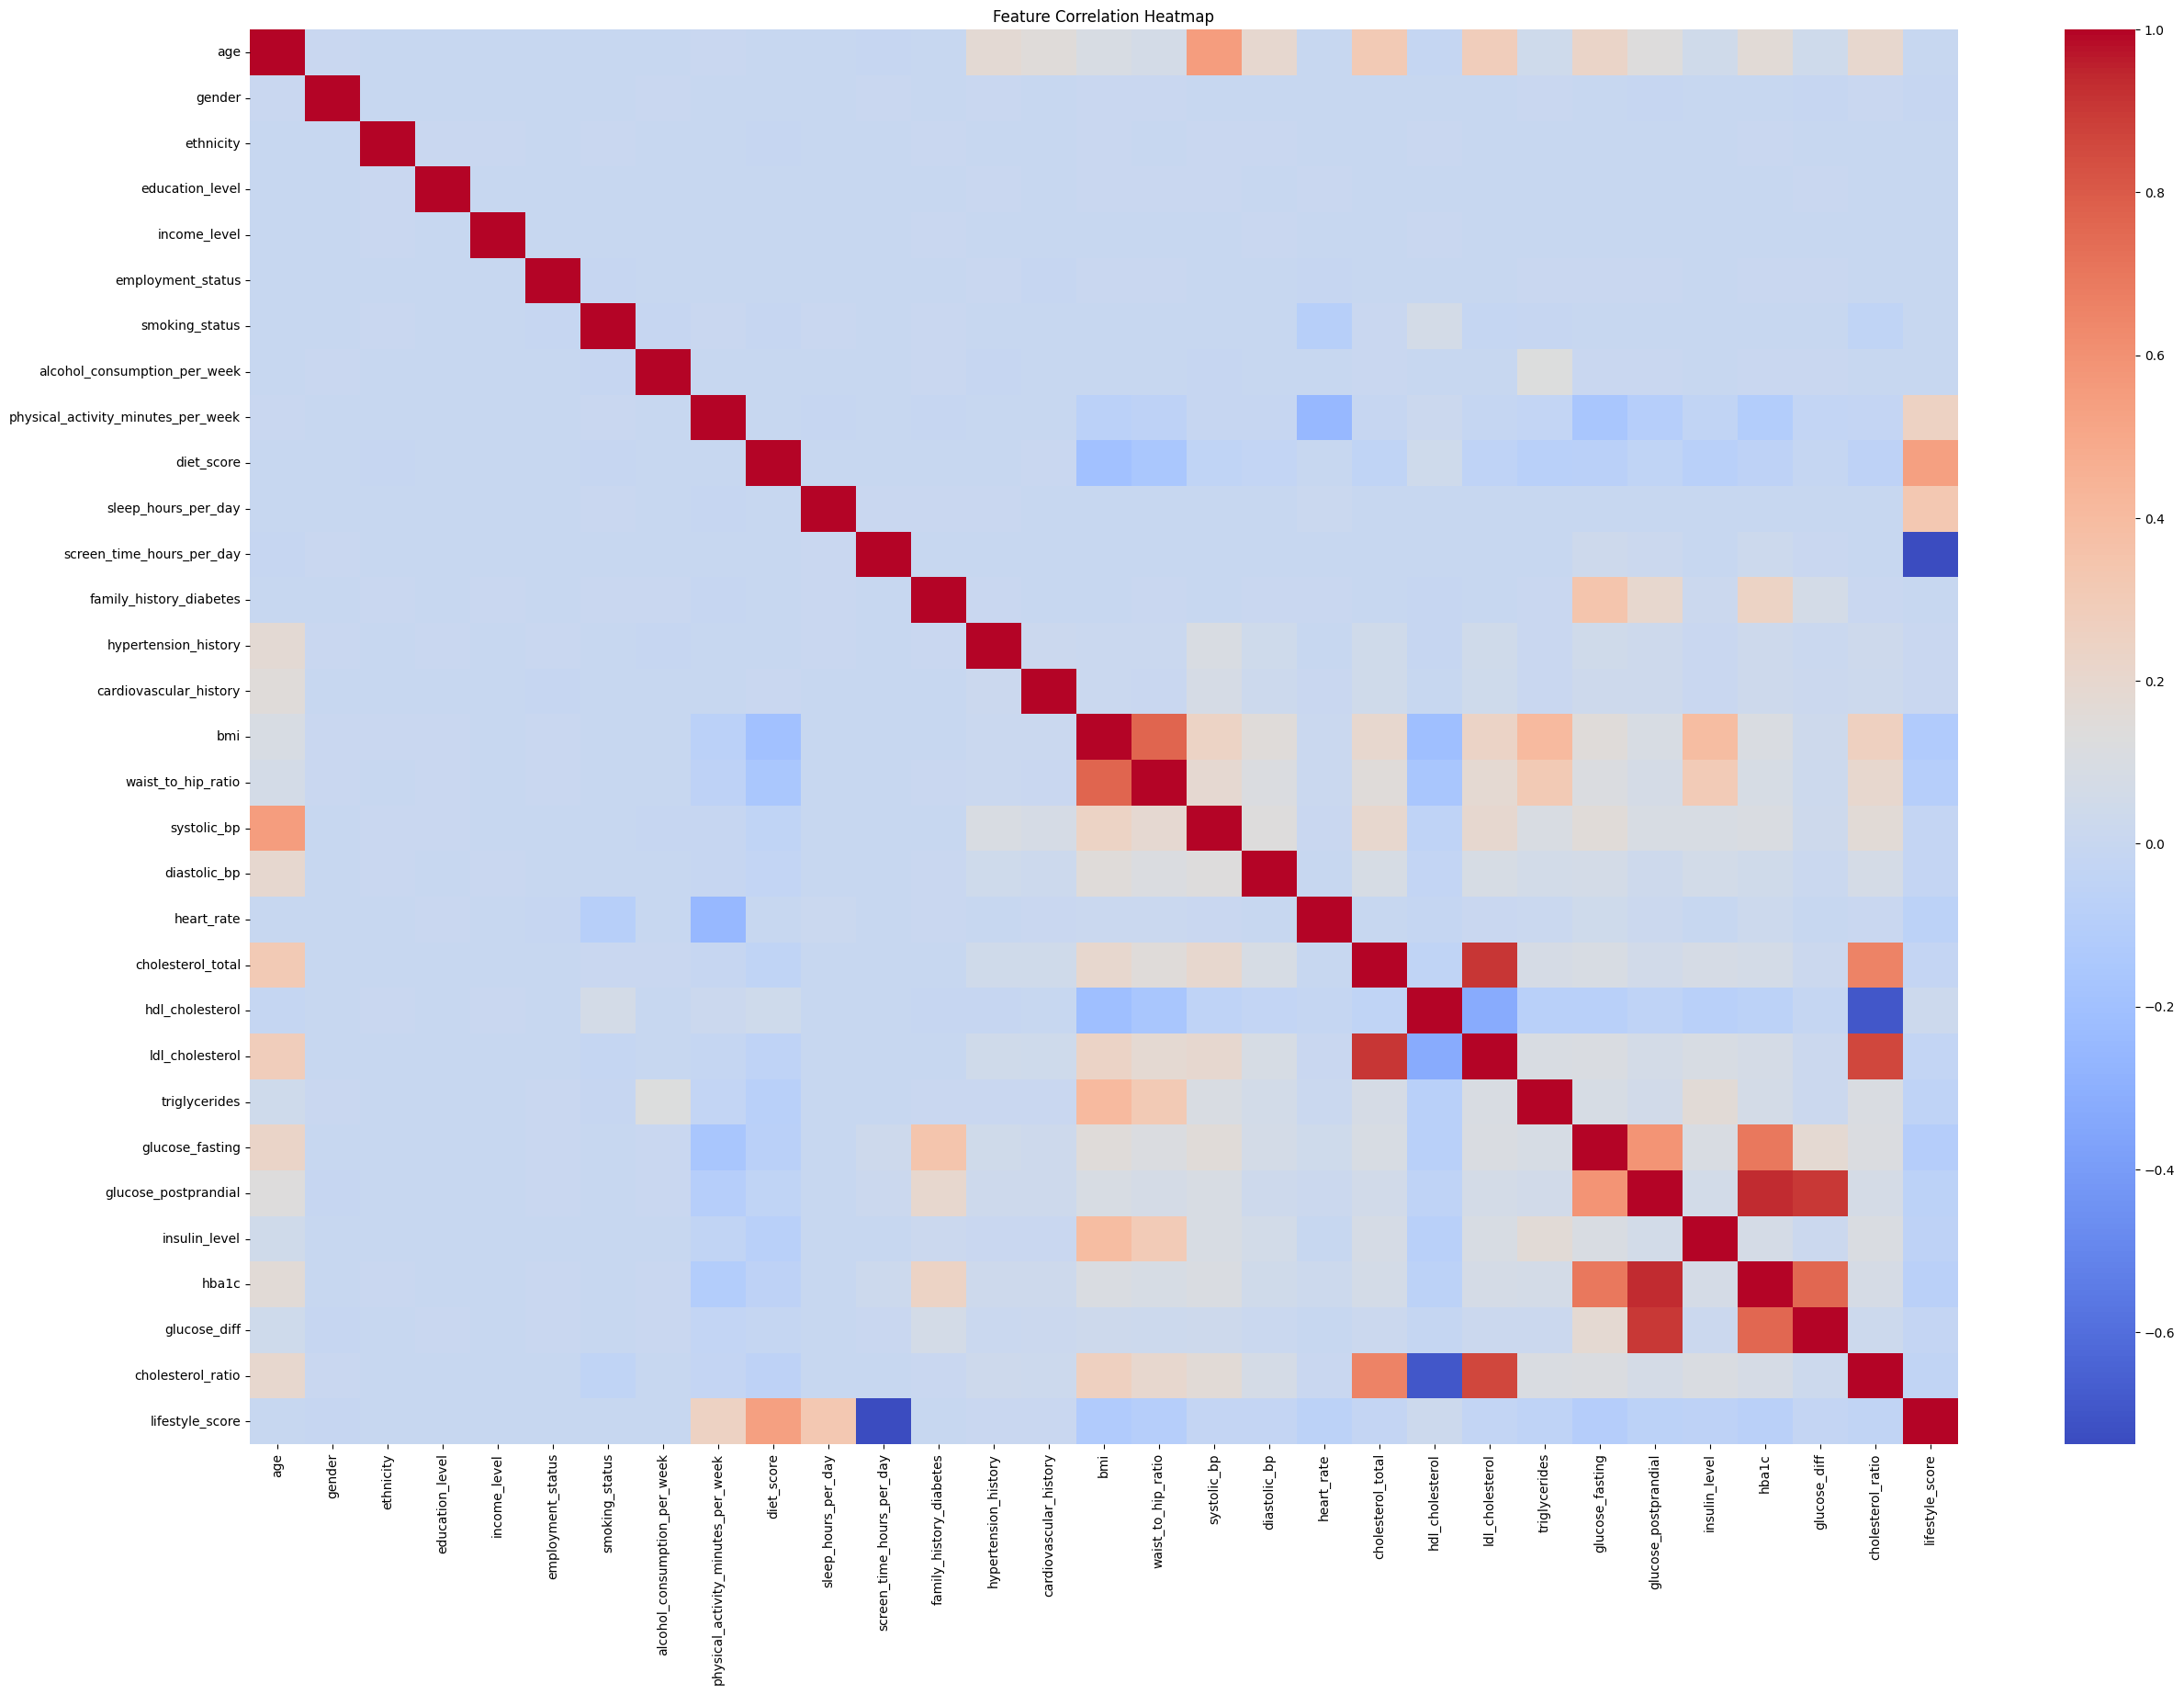

Highly correlated feature pairs (|r| > 0.8):
ldl_cholesterol vs cholesterol_total collinearity: 0.906
hba1c vs glucose_postprandial collinearity: 0.933
glucose_diff vs glucose_postprandial collinearity: 0.902
cholesterol_ratio vs ldl_cholesterol collinearity: 0.859

Dropped Features due to multicollinearity:
['glucose_diff', 'ldl_cholesterol', 'cholesterol_total', 'glucose_postprandial']

Accuracy for different numbers of features (5-fold CV):
5 features: 0.8236
6 features: 0.8241
7 features: 0.8241
8 features: 0.8240
9 features: 0.8244
10 features: 0.8245
11 features: 0.8246
12 features: 0.8246
13 features: 0.8246
14 features: 0.8241
15 features: 0.8242
16 features: 0.8241
17 features: 0.8240
18 features: 0.8241
19 features: 0.8241
20 features: 0.8242
21 features: 0.8242
22 features: 0.8241
23 features: 0.8241
24 features: 0.8241
25 features: 0.8241
26 features: 0.8241
27 features: 0.8241

Best number of features: 13
Best CV accuracy: 0.8246


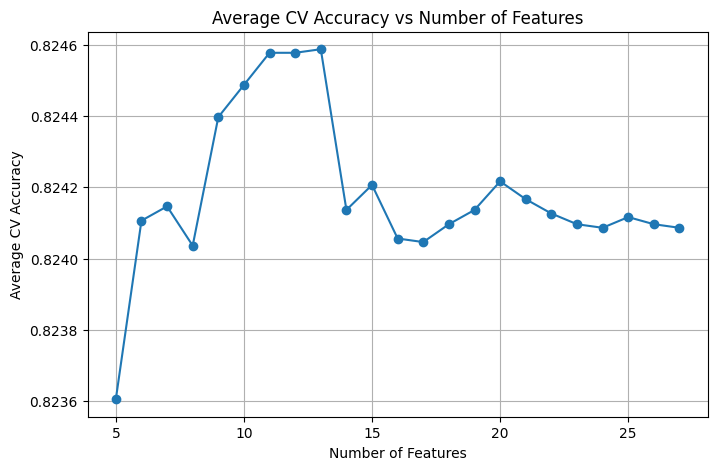


Selected Features:
['hba1c', 'glucose_fasting', 'family_history_diabetes', 'age', 'physical_activity_minutes_per_week', 'bmi', 'systolic_bp', 'waist_to_hip_ratio', 'cholesterol_ratio', 'lifestyle_score', 'insulin_level', 'triglycerides', 'hdl_cholesterol']


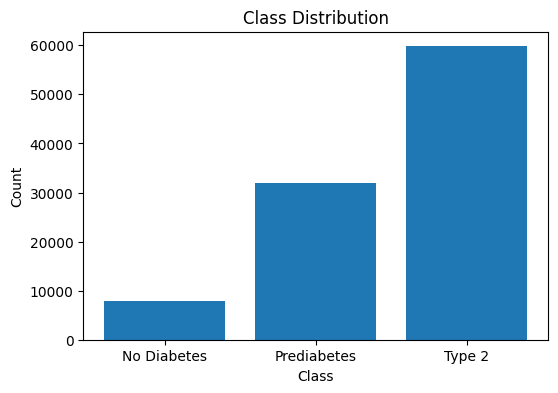

In [ ]:
# keep only 3 classes
df = df[df["diabetes_stage"].isin(["No Diabetes", "Pre-Diabetes", "Type 2"])].copy()


# map labels to numbers
label_map = {
    "No Diabetes": 0,
    "Pre-Diabetes": 1,
    "Type 2": 2
}
df["label"] = df["diabetes_stage"].map(label_map)

# drop columns
df = df.drop(["diabetes_stage", "diagnosed_diabetes", "diabetes_risk_score"], axis=1, errors="ignore")

###### Feature Engineering ######

# glucose difference
df["glucose_diff"] = df["glucose_postprandial"] - df["glucose_fasting"]

# cholesterol ratio
df["cholesterol_ratio"] = df["ldl_cholesterol"] / df["hdl_cholesterol"]

# lifestyle score
df["lifestyle_score"] = (
    df["diet_score"]
    + df["physical_activity_minutes_per_week"] / 100
    + df["sleep_hours_per_day"]
    - df["screen_time_hours_per_day"]
)

# encode categorical columns into numeric
df_encoded = df.copy()

cat_cols = [
    "gender",
    "ethnicity",
    "employment_status",
    "smoking_status",
    "income_level",
    "education_level"
]

for col in cat_cols:
    freq_map = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freq_map)


###### Pearson Correlation for Multicollinearity ######

# correlation matrix before dropping features
corr_matrix = df_encoded.corr(method="pearson")

# heatmap before dropping features
corr = df_encoded.drop(columns=["label"]).corr(method="pearson")
plt.figure(figsize=(30, 20))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# find highly correlated feature pairs
threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_value
            ))

print("Highly correlated feature pairs (|r| > 0.8):")
for f1, f2, r in high_corr_pairs:
    print(f"{f1} vs {f2} collinearity: {r:.3f}")

# drop one feature from each highly correlated pair
# keep the one more correlated with the label
to_drop = set()

for f1, f2, r in high_corr_pairs:
    corr_f1 = abs(corr_matrix.loc[f1, "label"])
    corr_f2 = abs(corr_matrix.loc[f2, "label"])

    if corr_f1 < corr_f2:
        to_drop.add(f1)
    else:
        to_drop.add(f2)

# never drop label
to_drop.discard("label")

print("\nDropped Features due to multicollinearity:")
print(list(to_drop))
df_encoded = df_encoded.drop(columns=list(to_drop), errors="ignore")


###### Feature Selection ######

# compute feature correlation with label
corr_with_label = df_encoded.corr()["label"].abs().sort_values(ascending=False)

# remove label itself
feature_ranking = corr_with_label.drop("label")

# test different numbers of features
results = []
best_k = 0
best_score = 0

# try all features
max_k = len(feature_ranking)

X = df_encoded[feature_ranking.index]
y = df_encoded["label"]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()  # initialize scaler

for k in range(5, max_k+1):  # start from 5 features
    top_features = feature_ranking.head(k).index
    acc_scores = []

    for train_index, test_index in kf.split(X, y):
        X_train, X_test = X.iloc[train_index][top_features], X.iloc[test_index][top_features]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # scale within each fold
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = LogisticRegression(max_iter=2000)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc_scores.append(accuracy_score(y_test, y_pred))

    mean_acc = np.mean(acc_scores)
    results.append((k, mean_acc))

    if mean_acc > best_score:
        best_score = mean_acc
        best_k = k

print("\nAccuracy for different numbers of features (5-fold CV):")
for k, acc in results:
    print(f"{k} features: {acc:.4f}")

print("\nBest number of features:", best_k)
print("Best CV accuracy:", round(best_score, 4))

# plot performance vs number of features
ks = [r[0] for r in results]
scores = [r[1] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(ks, scores, marker="o")
plt.title("Average CV Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Average CV Accuracy")
plt.grid(True)
plt.show()

# select best features
selected_features = feature_ranking.head(best_k).index.tolist()

# only keep these features + label
df_selected = df_encoded[selected_features + ["label"]]

print("\nSelected Features:")
print(selected_features)

###### Class Distribution Plot ######

counts = df_selected["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Diabetes", "Prediabetes", "Type 2"], counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

##Modeling algorithm and evaluation

In [ ]:
CLASS_NAMES = ["No Diabetes", "Pre-Diabetes", "Type 2"]
X = df_encoded[selected_features].values
y = df_encoded["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples\n")

# train 4 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    results[name] = {
        "model":    model,
        "y_pred":   y_pred,
        "acc":      accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "cv":       cv_scores.mean(),
        "cv_std":   cv_scores.std(),
        "cm":       confusion_matrix(y_test, y_pred),
        "report":   classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True),
    }
model_names = list(results.keys())

print(f"{'Model':<22} {'Accuracy':>10} {'Macro F1':>10} {'CV':>8}")
for name, r in results.items():
    print(f"{name:<22} {r['acc']:>10.4f} {r['f1_macro']:>10.4f} {r['cv']:>8.4f}")
best = max(results, key=lambda n: results[n]["f1_macro"])
print(f"\nBest model: {best}  (Macro F1 = {results[best]['f1_macro']:.4f})")

Train: 79680 samples  |  Test: 19920 samples

Model                    Accuracy   Macro F1       CV
Logistic Regression        0.8241     0.7792   0.8247
Decision Tree              0.9214     0.9177   0.9195
Random Forest              0.9222     0.9196   0.9207
XGBoost                    0.9221     0.9190   0.9204

Best model: Random Forest  (Macro F1 = 0.9196)


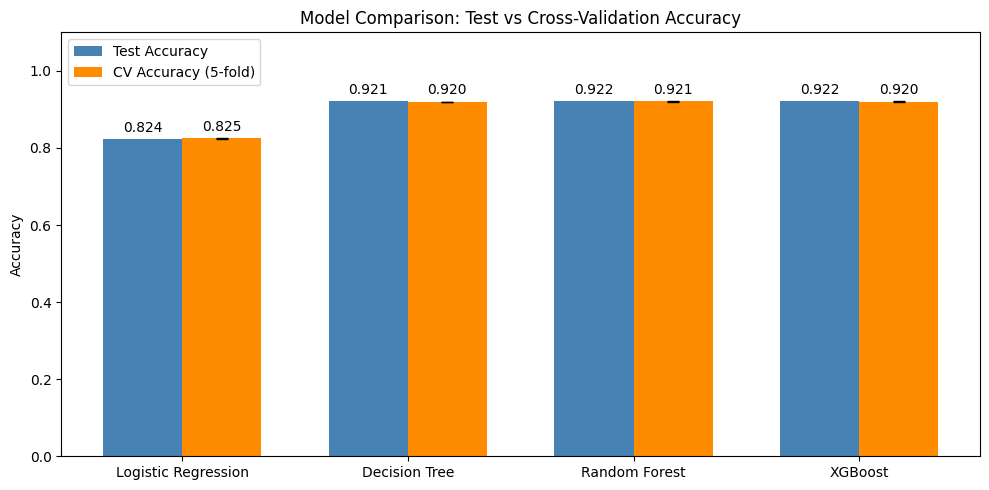

In [ ]:
# model comparison (Test vs CV Accuracy)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results[m]["acc"] for m in model_names], w,
            label="Test Accuracy", color="steelblue")
b2 = ax.bar(x + w/2, [results[m]["cv"]  for m in model_names], w,
            label="CV Accuracy (5-fold)", color="darkorange",
            yerr=[results[m]["cv_std"] for m in model_names], capsize=4)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison: Test vs Cross-Validation Accuracy")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

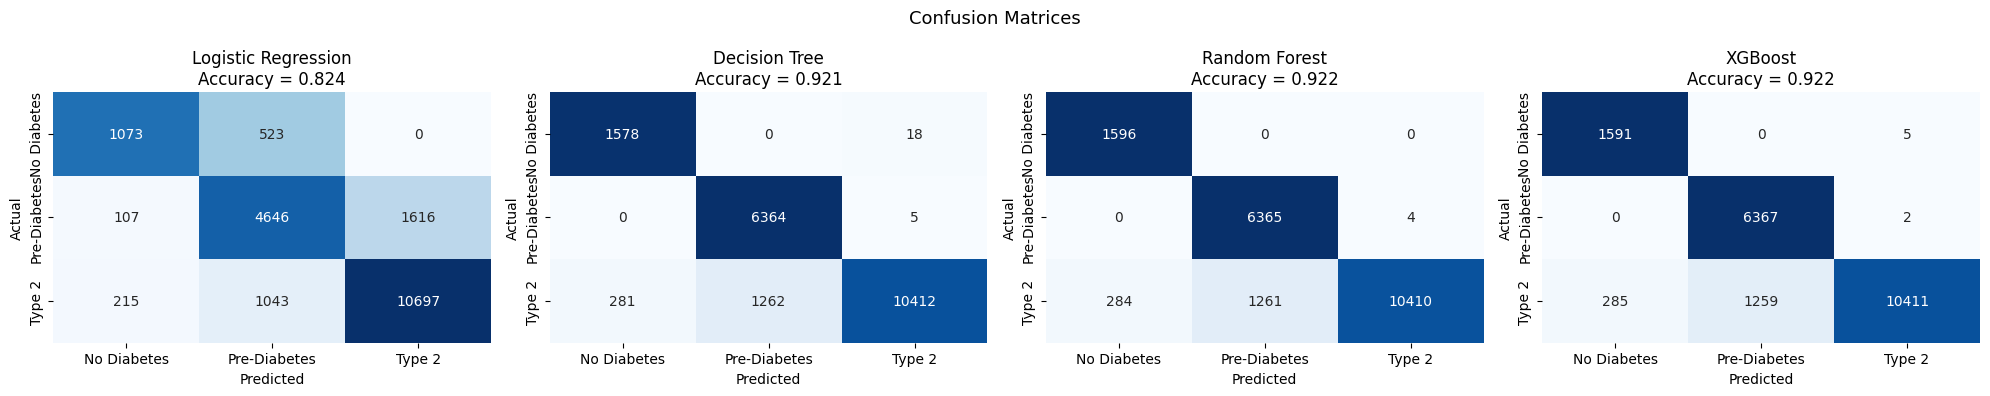

In [ ]:
# confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, model_names):
    cm = results[name]["cm"]
    sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True),
                annot=cm, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nAccuracy = {results[name]['acc']:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=13)
plt.tight_layout()
plt.show()

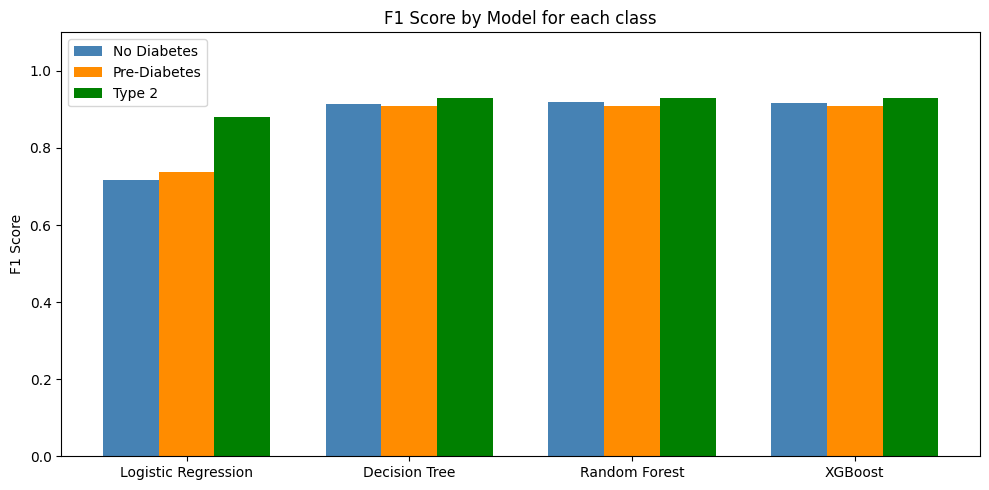

In [ ]:
# F1 score for each class
colors = ["steelblue", "darkorange", "green"]
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.25
for i, cls in enumerate(CLASS_NAMES):
    ax.bar(x + i*w, [results[m]["report"][cls]["f1-score"] for m in model_names],
           w, label=cls, color=colors[i])
ax.set_xticks(x + w); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("F1 Score")
ax.set_title("F1 Score by Model for each class"); ax.legend()
plt.tight_layout()
plt.show()

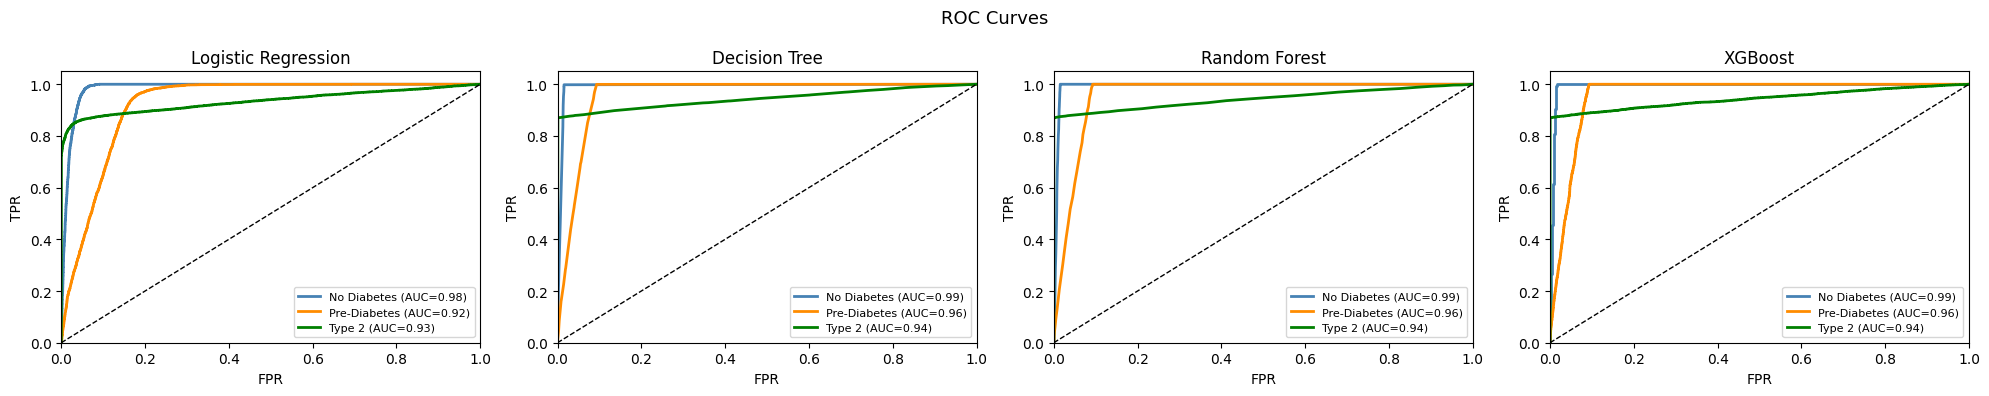

In [ ]:
# ROC curves
y_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, model_names):
    y_prob = results[name]["model"].predict_proba(X_test)
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{cls} (AUC={auc(fpr,tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title(name); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=8); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.suptitle("ROC Curves", fontsize=13)
plt.tight_layout()
plt.show()

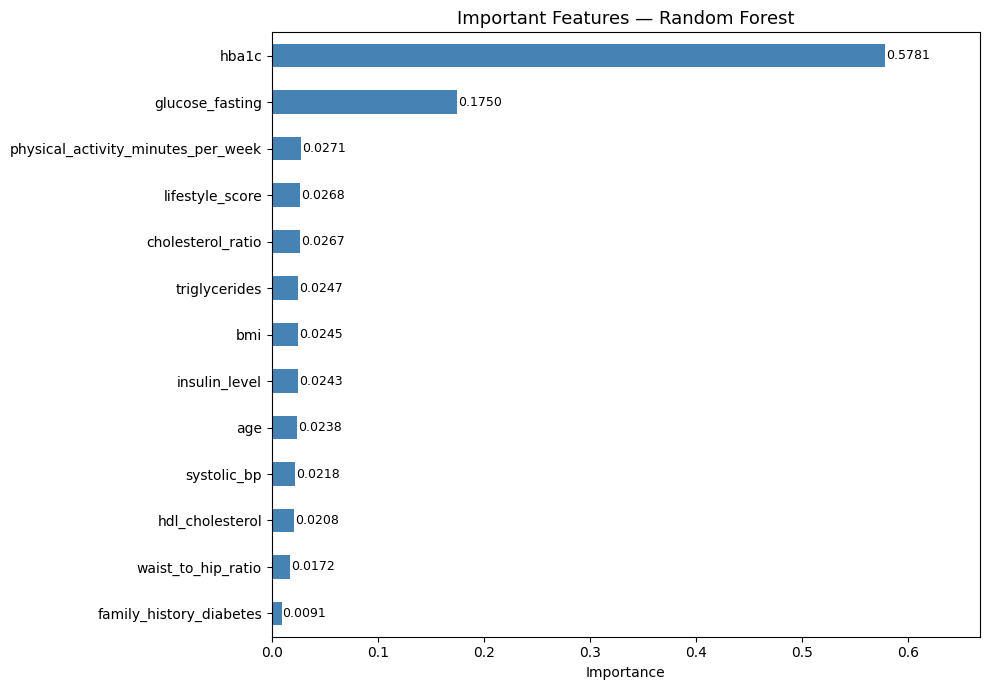

In [ ]:
# Feature Importance — Random Forest
rf = results["Random Forest"]["model"]
imp = pd.Series(rf.feature_importances_, index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
imp.plot.barh(ax=ax, color="steelblue")

# Add percentage labels to the end of each bar
total = imp.sum()
for bar, value in zip(ax.patches, imp.values):
    pct = value / total
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.4f}",
        va="center", fontsize=9
    )

ax.set_xlim(right=ax.get_xlim()[1] * 1.1)
ax.set_title("Important Features — Random Forest", fontsize=13)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# summary
print(f"{'Model':<22} {'Test Accuracy':>9} {'CV Accuracy':>8} {'Macro F1':>9}")
for name in model_names:
    r = results[name]["report"]
    print(f"{name:<22} {results[name]['acc']:>13.4f} {results[name]['cv']:>11.4f} {r['macro avg']['f1-score']:>9.4f}")

best = max(results, key=lambda m: results[m]["acc"])
print(f"\nBest model: {best}  (Accuracy = {results[best]['acc']:.4f})")
print("\n" + classification_report(y_test, results[best]["y_pred"], target_names=CLASS_NAMES))

Model                  Test Accuracy CV Accuracy  Macro F1
Logistic Regression           0.8241      0.8247    0.7792
Decision Tree                 0.9214      0.9195    0.9177
Random Forest                 0.9222      0.9207    0.9196
XGBoost                       0.9221      0.9204    0.9190

Best model: Random Forest  (Accuracy = 0.9222)

              precision    recall  f1-score   support

 No Diabetes       0.85      1.00      0.92      1596
Pre-Diabetes       0.83      1.00      0.91      6369
      Type 2       1.00      0.87      0.93     11955

    accuracy                           0.92     19920
   macro avg       0.89      0.96      0.92     19920
weighted avg       0.93      0.92      0.92     19920



## Model visualization and hyperparameter optimization

In [ ]:
# Create a pipeline for scaling
# Currently not using this in the script
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state = 42))
])

In [ ]:
# Logistic Regression hyperparameter tuning

# Define hyperparameters (will be used for all search algorithms)
lg_hyperparameters = {
    'penalty': [None, 'l2'],
    'tol': [0.005, 0.01, 0.025],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['sag', 'saga'],
    'max_iter': [25, 50, 100, 250, 500]
}

# Define our model
logistic_regression = LogisticRegression(random_state = 42);

In [ ]:
# Grid Search

# Perform grid search on our training data
# Accuracy
lg_grid_search_acc = GridSearchCV(logistic_regression, lg_hyperparameters, n_jobs = -1, cv = 5, refit = 'accuracy',
                              scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
lg_grid_search_acc.fit(X_train, y_train);

# Macro F1
lg_grid_search_f1 = GridSearchCV(logistic_regression, lg_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                              scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
lg_grid_search_f1.fit(X_train, y_train);

# Print out results
print("Logistic Regression Hyperparameter Tuning Results (Grid Search)\n")

print("Accuracy")
print("Top Hyperparameters:", lg_grid_search_acc.best_params_)
print(f"Top CV Scores: {lg_grid_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {lg_grid_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", lg_grid_search_f1.best_params_)
print(f"Top CV Scores: {lg_grid_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {lg_grid_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Logistic Regression Hyperparameter Tuning Results (Grid Search)

Accuracy
Top Hyperparameters: {'C': 0.01, 'max_iter': 25, 'penalty': None, 'solver': 'sag', 'tol': 0.01}
Top CV Scores: 0.8252
Test Accuracy: 0.8241

Macro F1
Top Hyperparameters: {'C': 1, 'max_iter': 25, 'penalty': 'l2', 'solver': 'sag', 'tol': 0.01}
Top CV Scores: 0.7832
Test Accuracy: 0.7788


In [ ]:
# Randomized Search

# Perform randomized search on our training data
# Accuracy
lg_random_search_acc = RandomizedSearchCV(logistic_regression, lg_hyperparameters, n_jobs = -1, cv = 5, refit = 'accuracy',
                                      scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
lg_random_search_acc.fit(X_train, y_train);

# Macro F1
lg_random_search_f1 = RandomizedSearchCV(logistic_regression, lg_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                                      scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
lg_random_search_f1.fit(X_train, y_train);

# Print out results
print("Logistic Regression Hyperparameter Tuning Results (Randomized Search)\n")

print("Accuracy")
print("Top Hyperparameters:", lg_random_search_acc.best_params_)
print(f"Top CV Scores: {lg_random_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {lg_random_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", lg_random_search_f1.best_params_)
print(f"Top CV Scores: {lg_random_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {lg_random_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


Logistic Regression Hyperparameter Tuning Results (Randomized Search)

Accuracy
Top Hyperparameters: {'tol': 0.01, 'solver': 'sag', 'penalty': None, 'max_iter': 50, 'C': 10}
Top CV Scores: 0.8252
Test Accuracy: 0.8241

Macro F1
Top Hyperparameters: {'tol': 0.01, 'solver': 'sag', 'penalty': None, 'max_iter': 50, 'C': 10}
Top CV Scores: 0.7831
Test Accuracy: 0.7793


In [ ]:
# Decision Tree hyperparameter tuning

# Define hyperparameters (will be used for all search algorithms)
dt_hyperparameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 3],
    'max_features': [None, 'sqrt', 'log2']
}

# Define our model
decision_tree = DecisionTreeClassifier(random_state = 42)

In [ ]:
# Grid Search

# Perform grid search on our training data
# Accuracy
dt_grid_search_acc = GridSearchCV(decision_tree, dt_hyperparameters, n_jobs = -1, cv = 5, refit = 'accuracy',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
dt_grid_search_acc.fit(X_train, y_train);

# Macro F1
dt_grid_search_f1 = GridSearchCV(decision_tree, dt_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
dt_grid_search_f1 .fit(X_train, y_train);

# Print out results
print("Decision Tree Hyperparameter Tuning Results (Grid Search)")

print("Accuracy")
print("Top Hyperparameters:", dt_grid_search_acc.best_params_)
print(f"Top CV Scores: {dt_grid_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {dt_grid_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", dt_grid_search_f1.best_params_)
print(f"Top CV Scores: {dt_grid_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {dt_grid_search_f1.score(X_test, y_test):.4f}")

# Other possible tuning options
# Bayesian Optimization


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Decision Tree Hyperparameter Tuning Results (Grid Search)
Accuracy
Top Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Top CV Scores: 0.9209
Test Accuracy: 0.9223

Macro F1
Top Hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Top CV Scores: 0.9191
Test Accuracy: 0.9196


In [ ]:
# Randomized Search

# Perform randomized search on our training data
# Accuracy
dt_random_search_acc = RandomizedSearchCV(decision_tree, dt_hyperparameters, n_jobs = -1, cv = 5, refit = 'accuracy',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
dt_random_search_acc.fit(X_train, y_train);

# Macro F1
dt_random_search_f1 = RandomizedSearchCV(decision_tree, dt_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
dt_random_search_f1.fit(X_train, y_train);

# Print out results
print("Decision Tree Hyperparameter Tuning Results (Randomized Search)\n")

print("Accuracy")
print("Top Hyperparameters:", dt_random_search_acc.best_params_)
print(f"Top CV Scores: {dt_random_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {dt_random_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", dt_random_search_f1.best_params_)
print(f"Top CV Scores: {dt_random_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {dt_random_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Decision Tree Hyperparameter Tuning Results (Randomized Search)

Accuracy
Top Hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy'}
Top CV Scores: 0.9209
Test Accuracy: 0.9223

Macro F1
Top Hyperparameters: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy'}
Top CV Scores: 0.9191
Test Accuracy: 0.9196


In [ ]:
# Random Forest hyperparameter tuning

# Define hyperparameters (will be used for all search algorithms)
rf_hyperparameters = {
    'n_estimators': [100, 150, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True]
}

# Define our model
random_forest = RandomForestClassifier(random_state = 42)

In [ ]:
# Grid Search

# Perform randomized search on our training data
# Accuracy
rf_grid_search_acc = GridSearchCV(random_forest, rf_hyperparameters, n_jobs = -1, cv = 5, refit = 'accuracy',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
rf_grid_search_acc.fit(X_train, y_train);

# Macro F1
rf_grid_search_f1 = GridSearchCV(random_forest, rf_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
rf_grid_search_f1.fit(X_train, y_train);

# Print out results
print("Random Forest Hyperparameter Tuning Results (Grid Search)\n")

print("Accuracy")
print("Top Hyperparameters:", rf_grid_search_acc.best_params_)
print(f"Top CV Scores: {rf_grid_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {rf_grid_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", rf_grid_search_f1.best_params_)
print(f"Top CV Scores: {rf_grid_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {rf_grid_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Random Forest Hyperparameter Tuning Results (Grid Search)

Accuracy
Top Hyperparameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Top CV Scores: 0.9209
Test Accuracy: 0.9224

Macro F1
Top Hyperparameters: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Top CV Scores: 0.9191
Test Accuracy: 0.9197


In [ ]:
# Randomized Search

# Perform randomized search on our training data
# Accuracy
rf_random_search_acc = RandomizedSearchCV(random_forest, rf_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
rf_random_search_acc.fit(X_train, y_train);

# Macro F1
rf_random_search_f1 = RandomizedSearchCV(random_forest, rf_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
rf_random_search_f1.fit(X_train, y_train);

# Print out results
print("Random Forest Hyperparameter Tuning Results (Randomized Search)\n")

print("Accuracy")
print("Top Hyperparameters:", rf_random_search_acc.best_params_)
print(f"Top CV Scores: {rf_random_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {rf_random_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", rf_random_search_f1.best_params_)
print(f"Top CV Scores: {rf_random_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {rf_random_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Forest Hyperparameter Tuning Results (Randomized Search)

Accuracy
Top Hyperparameters: {'n_estimators': 200, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'gini', 'bootstrap': True}
Top CV Scores: 0.9191
Test Accuracy: 0.9197

Macro F1
Top Hyperparameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 15, 'criterion': 'entropy', 'bootstrap': True}
Top CV Scores: 0.9191
Test Accuracy: 0.9197


In [ ]:
# XGBoost hyperparameter tuning

# Define hyperparameters (will be used for all search algorithms)
xgb_hyperparameters = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'min_child_weight': [1, 3, 5],
    'eval_metric': ['mlogloss', 'auc']
}

# Define our model
xgb = XGBClassifier(random_state = 42)

In [ ]:
# Grid Search

# Perform randomized search on our training data
# Accuracy
xgb_grid_search_acc = GridSearchCV(xgb, xgb_hyperparameters, n_jobs = -1, cv = 5, refit = 'accuracy',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
xgb_grid_search_acc.fit(X_train, y_train);

# Macro F1
xgb_grid_search_f1 = GridSearchCV(xgb, xgb_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
xgb_grid_search_f1.fit(X_train, y_train);

# Print out results
print("XGBoost Hyperparameter Tuning Results (Grid Search)\n")

print("Accuracy")
print("Top Hyperparameters:", xgb_grid_search_acc.best_params_)
print(f"Top CV Scores: {xgb_grid_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {xgb_grid_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", xgb_grid_search_f1.best_params_)
print(f"Top CV Scores: {xgb_grid_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {xgb_grid_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Random Forest Hyperparameter Tuning Results (Grid Search)

Accuracy
Top Hyperparameters: {'colsample_bytree': 0.8, 'eval_metric': 'mlogloss', 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}
Top CV Scores: 0.9209
Test Accuracy: 0.9224

Macro F1
Top Hyperparameters: {'colsample_bytree': 0.8, 'eval_metric': 'mlogloss', 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}
Top CV Scores: 0.9191
Test Accuracy: 0.9196


In [ ]:
# Randomized Search

# Perform randomized search on our training data
# Accuracy
xgb_random_search_acc = RandomizedSearchCV(xgb, xgb_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
xgb_random_search_acc.fit(X_train, y_train);

# Macro F1
xgb_random_search_f1 = RandomizedSearchCV(xgb, xgb_hyperparameters, n_jobs = -1, cv = 5, refit = 'f1_macro',
                           scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}, verbose = 2);
xgb_random_search_f1.fit(X_train, y_train);

# Print out results
print("Random Forest Hyperparameter Tuning Results (Randomized Search)\n")

print("Accuracy")
print("Top Hyperparameters:", xgb_random_search_acc.best_params_)
print(f"Top CV Scores: {xgb_random_search_acc.best_score_:.4f}")
print(f"Test Accuracy: {xgb_random_search_acc.score(X_test, y_test):.4f}")

print("\nMacro F1")
print("Top Hyperparameters:", xgb_random_search_f1.best_params_)
print(f"Top CV Scores: {xgb_random_search_f1.best_score_:.4f}")
print(f"Test Accuracy: {xgb_random_search_f1.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Forest Hyperparameter Tuning Results (Randomized Search)

Accuracy
Top Hyperparameters: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'eval_metric': 'mlogloss', 'colsample_bytree': 0.6}
Top CV Scores: 0.9191
Test Accuracy: 0.9195

Macro F1
Top Hyperparameters: {'subsample': 0.6, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'eval_metric': 'auc', 'colsample_bytree': 0.8}
Top CV Scores: 0.9191
Test Accuracy: 0.9195


In [ ]:
# Consolidate results
# Grid Search CV Accuracy & Test
results_grid_acc = {'Logistic Regression': lg_grid_search_acc.best_score_, 'Decision Tree': dt_grid_search_acc.best_score_,
                    'Random Forest': rf_grid_search_acc.best_score_, 'XGBoost': xgb_grid_search_acc.best_score_}
results_grid_acc_test = {'Logistic Regression': lg_grid_search_acc.score(X_test, y_test), 'Decision Tree': dt_grid_search_acc.score(X_test, y_test),
                         'Random Forest': rf_grid_search_acc.score(X_test, y_test), 'XGBoost': xgb_grid_search_acc.score(X_test, y_test)}

# Grid Search CV Macro F1 & Test
results_grid_f1 = {'Logistic Regression': lg_grid_search_f1.best_score_, 'Decision Tree': dt_grid_search_f1.best_score_,
                   'Random Forest': rf_grid_search_f1.best_score_, 'XGBoost': xgb_grid_search_f1.best_score_}
results_grid_f1_test = {'Logistic Regression': lg_grid_search_f1.score(X_test, y_test), 'Decision Tree': dt_grid_search_f1.score(X_test, y_test),
                        'Random Forest': rf_grid_search_f1.score(X_test, y_test), 'XGBoost': xgb_grid_search_f1.score(X_test, y_test)}

# Random Search CV Accuracy & Test
results_random_acc = {'Logistic Regression': lg_random_search_acc.best_score_, 'Decision Tree': dt_random_search_acc.best_score_,
                      'Random Forest': rf_random_search_acc.best_score_, 'XGBoost': xgb_random_search_acc.best_score_}
results_random_acc_test = {'Logistic Regression': lg_random_search_acc.score(X_test, y_test), 'Decision Tree': dt_random_search_acc.score(X_test, y_test),
                           'Random Forest': rf_random_search_acc.score(X_test, y_test), 'XGBoost': xgb_random_search_acc.score(X_test, y_test)}

# Random Search CV Macro F1 & Test
results_random_f1 = {'Logistic Regression': lg_random_search_f1.best_score_, 'Decision Tree': dt_random_search_f1.best_score_,
                     'Random Forest': rf_random_search_f1.best_score_, 'XGBoost': xgb_random_search_f1.best_score_}
results_random_f1_test = {'Logistic Regression': lg_random_search_f1.score(X_test, y_test), 'Decision Tree': dt_random_search_f1.score(X_test, y_test),
                          'Random Forest': rf_random_search_f1.score(X_test, y_test), 'XGBoost': xgb_random_search_f1.score(X_test, y_test)}

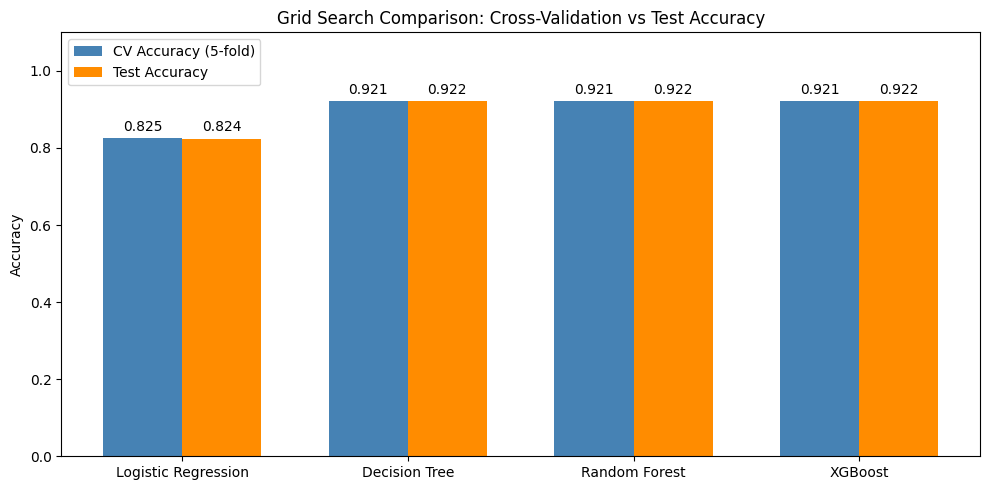

In [ ]:
# Grid Search results comparison (CV Accuracy vs Test Accuracy)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_grid_acc[m] for m in model_names], w,
            label="CV Accuracy (5-fold)", color="steelblue")
b2 = ax.bar(x + w/2, [results_grid_acc_test[m] for m in model_names], w,
            label="Test Accuracy", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy")
ax.set_title("Grid Search Comparison: Cross-Validation vs Test Accuracy")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

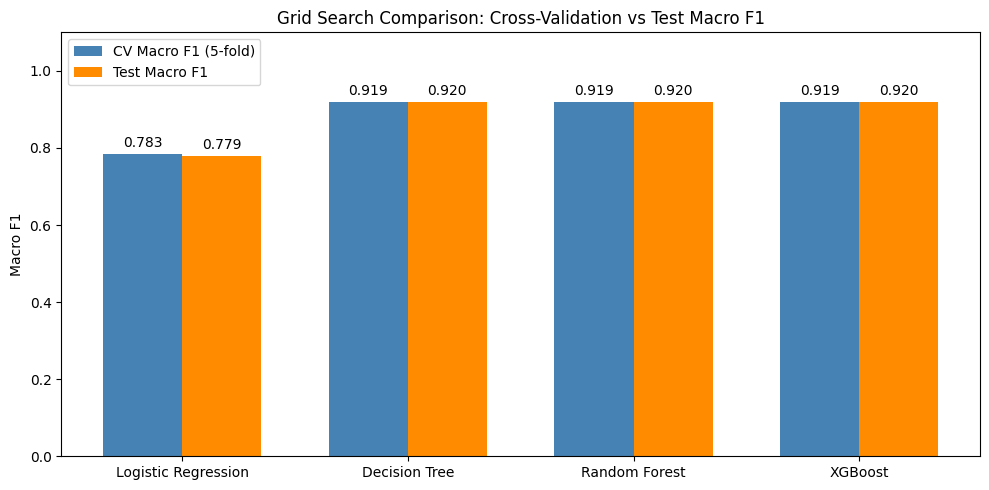

In [ ]:
# Grid Search results comparison (CV Macro F1 vs Test Macro F1)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_grid_f1[m] for m in model_names], w,
            label="CV Macro F1 (5-fold)", color="steelblue")
b2 = ax.bar(x + w/2, [results_grid_f1_test[m] for m in model_names], w,
            label="Test Macro F1", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Macro F1")
ax.set_title("Grid Search Comparison: Cross-Validation vs Test Macro F1")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

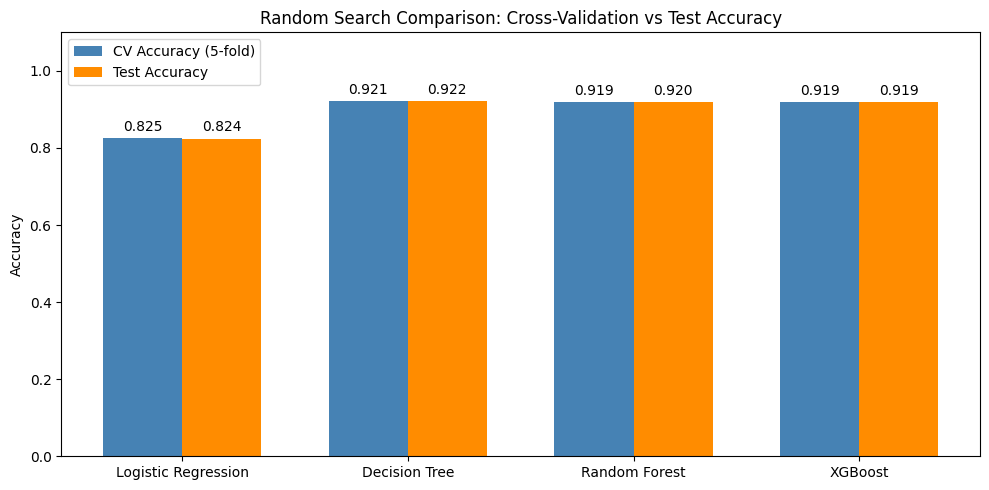

In [ ]:
# Random Search results comparison (CV Accuracy vs Test Accuracy)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_random_acc[m] for m in model_names], w,
            label="CV Accuracy (5-fold)", color="steelblue")
b2 = ax.bar(x + w/2, [results_random_acc_test[m] for m in model_names], w,
            label="Test Accuracy", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy")
ax.set_title("Random Search Comparison: Cross-Validation vs Test Accuracy")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

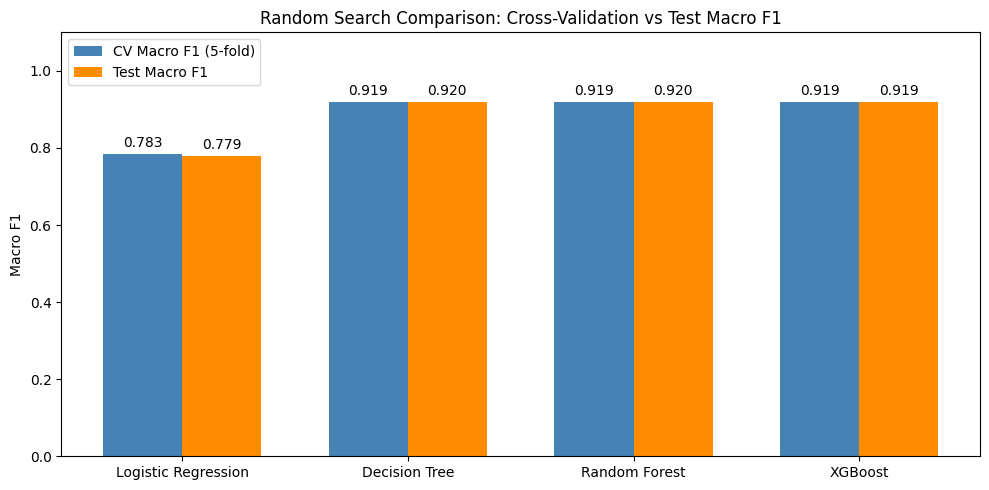

In [ ]:
# Random Search results comparison (CV Macro F1 vs Test Macro F1)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_random_f1[m] for m in model_names], w,
            label="CV Macro F1 (5-fold)", color="steelblue")
b2 = ax.bar(x + w/2, [results_random_f1_test[m] for m in model_names], w,
            label="Test Macro F1", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Macro F1")
ax.set_title("Random Search Comparison: Cross-Validation vs Test Macro F1")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

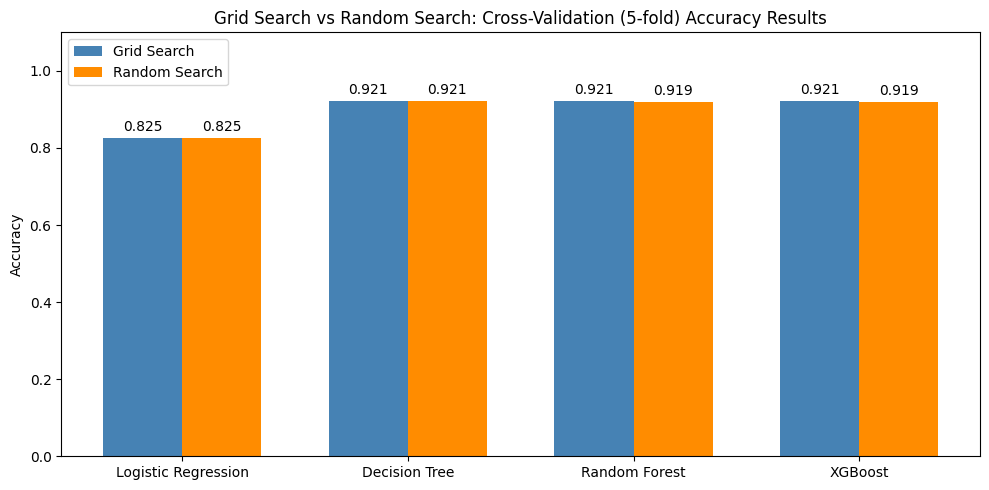

In [ ]:
# Grid Search vs Random Search results comparison (CV Accuracy)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_grid_acc[m] for m in model_names], w,
            label="Grid Search", color="steelblue")
b2 = ax.bar(x + w/2, [results_random_acc[m] for m in model_names], w,
            label="Random Search", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy")
ax.set_title("Grid Search vs Random Search: Cross-Validation (5-fold) Accuracy Results")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

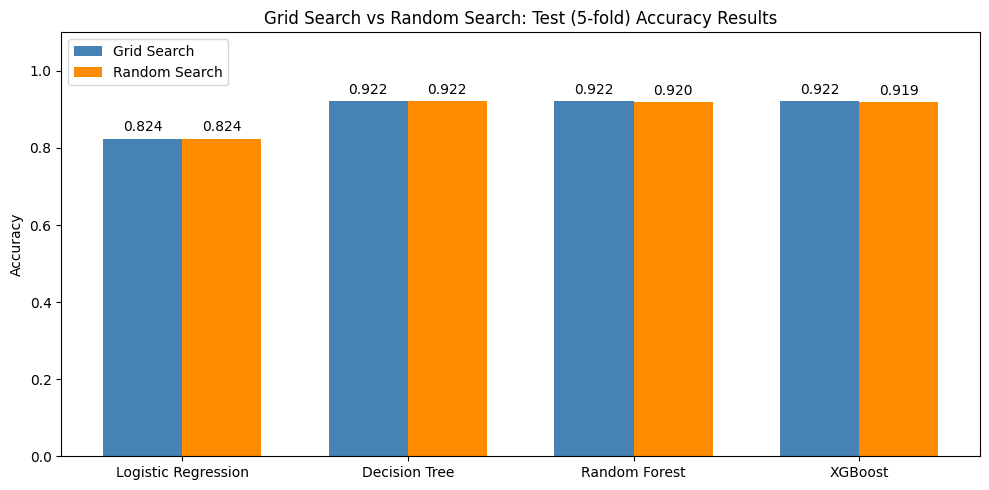

In [ ]:
# Grid Search vs Random Search results comparison (Test Accuracy)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_grid_acc_test[m] for m in model_names], w,
            label="Grid Search", color="steelblue")
b2 = ax.bar(x + w/2, [results_random_acc_test[m] for m in model_names], w,
            label="Random Search", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Accuracy")
ax.set_title("Grid Search vs Random Search: Test (5-fold) Accuracy Results")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

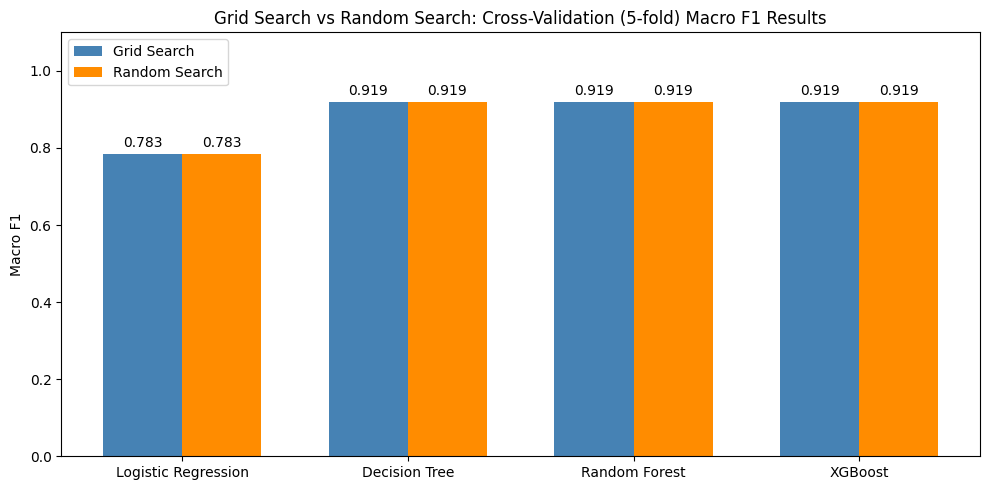

In [ ]:
# Grid Search vs Random Search results comparison (CV Macro F1)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_grid_f1[m] for m in model_names], w,
            label="Grid Search", color="steelblue")
b2 = ax.bar(x + w/2, [results_random_f1[m] for m in model_names], w,
            label="Random Search", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Macro F1")
ax.set_title("Grid Search vs Random Search: Cross-Validation (5-fold) Macro F1 Results")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

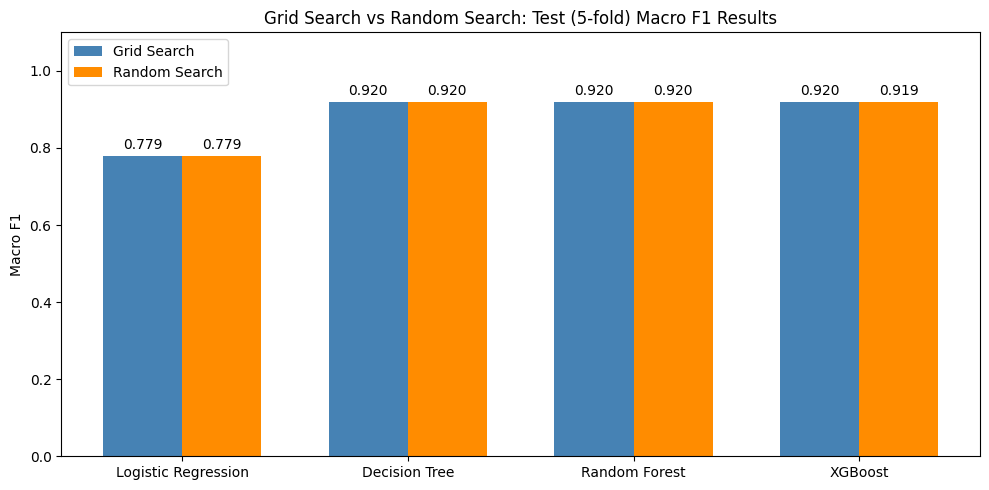

In [ ]:
# Grid Search vs Random Search results comparison (Test Macro F1)
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(model_names)), 0.35
b1 = ax.bar(x - w/2, [results_grid_f1_test[m] for m in model_names], w,
            label="Grid Search", color="steelblue")
b2 = ax.bar(x + w/2, [results_random_f1_test[m] for m in model_names], w,
            label="Random Search", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Macro F1")
ax.set_title("Grid Search vs Random Search: Test (5-fold) Macro F1 Results")
ax.legend(); ax.bar_label(b1, fmt="%.3f", padding=3); ax.bar_label(b2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

In [ ]:
# Consolidate best hyperparameters from tuning
best_params_grid_acc = [lg_grid_search_acc.best_params_, dt_grid_search_acc.best_params_, rf_grid_search_acc.best_params_, xgb_grid_search_acc.best_params_]
best_params_random_acc = [lg_random_search_acc.best_params_, dt_random_search_acc.best_params_, rf_random_search_acc.best_params_, xgb_random_search_acc.best_params_]
best_params_grid_f1 = [lg_grid_search_f1.best_params_, dt_grid_search_f1.best_params_, rf_grid_search_f1.best_params_, xgb_grid_search_f1.best_params_]
best_params_random_f1 = [lg_random_search_f1.best_params_, dt_random_search_f1.best_params_, rf_random_search_f1.best_params_, xgb_random_search_f1.best_params_]

In [ ]:
# Summarize the best hyperparameters for each model
print("Best Hyperparameters (CV 5-fold)\n")
print("Grid Search Hyperparameters (Accuracy)")
for name, params in zip(model_names, best_params_grid_acc):
  print(f"{name:<22}-> {params}")

print("\nRandom Search Hyperparameters (Accuracy)")
for name, params in zip(model_names, best_params_random_acc):
  print(f"{name:<22}-> {params}")

print("\nGrid Search Hyperparameters (Macro F1)")
for name, params in zip(model_names, best_params_grid_f1):
  print(f"{name:<22}-> {params}")

print("\nRandom Search Hyperparameters (Macro F1)")
for name, params in zip(model_names, best_params_random_f1):
  print(f"{name:<22}-> {params}")


Best Hyperparameters (CV 5-fold)

Grid Search Hyperparameters (Accuracy)
Logistic Regression   -> {'C': 0.01, 'max_iter': 25, 'penalty': None, 'solver': 'sag', 'tol': 0.01}
Decision Tree         -> {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Random Forest         -> {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
XGBoost               -> {'colsample_bytree': 0.8, 'eval_metric': 'mlogloss', 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}

Random Search Hyperparameters (Accuracy)
Logistic Regression   -> {'tol': 0.01, 'solver': 'sag', 'penalty': None, 'max_iter': 50, 'C': 10}
Decision Tree         -> {'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy'}
Random Forest         -> {'n_estimators': 200, 'min_samples_split': 3, 'min_samples_l

In [ ]:
# Summarize results after hyperparameter tuning
print("Hyperparameter Tuning Summary (CV 5-fold)\n")

print("Grid Search Results")
print(f"{'Model':<22} {'Accuracy':>10} {'Macro F1':>10} {'Test Accuracy':>15} {'Test Macro F1':>15} ")
for name, acc, f1, acc_test, f1_test in zip(model_names, results_grid_acc, results_grid_f1, results_grid_acc_test, results_grid_f1_test):
    print(f"{name:<22} {results_grid_acc[acc]:>9.5f} {results_grid_f1[f1]:>10.5f} {results_grid_acc_test[acc_test]:>10.5f} {results_grid_f1_test[f1_test]:>15.5f}")

print("\nRandom Search Results")
print(f"{'Model':<22} {'Accuracy':>10} {'Macro F1':>10} {'Test Accuracy':>15} {'Test Macro F1':>15} ")
for name, acc, f1, acc_test, f1_test in zip(model_names, results_random_acc, results_random_f1, results_random_acc_test, results_random_f1_test):
    print(f"{name:<22} {results_random_acc[acc]:>9.5f} {results_random_f1[f1]:>10.5f} {results_random_acc_test[acc_test]:>10.5f} {results_random_f1_test[f1_test]:>15.5f}")

print("\nPrevious Best Model Reults")

best = max(results, key=lambda n: results[n]["f1_macro"])
print(f"Best Model: {best}  (Macro F1 = {results[best]['f1_macro']:.5f})")

best = max(results, key=lambda m: results[m]["acc"])
print(f"Best Model: {best}  (Test Accuracy = {results[best]['acc']:.5f})")

print("\nNew Best Model Results")

best_acc = max(results_grid_acc, key = lambda m: results_grid_acc[m])
best_f1 = max(results_grid_f1, key = lambda m: results_grid_f1[m])
best_acc_test = max(results_grid_acc_test, key = lambda m: results_grid_acc_test[m])
best_f1_test = max(results_grid_f1_test, key = lambda m: results_grid_f1_test[m])

print(f"Best Model: {best_acc}  (Accuracy = {results_grid_acc[best_acc]:.5f})")
print(f"Best Model: {best_f1}  (Macro F1 = {results_grid_f1[best_f1]:.5f})")
print(f"Best Model: {best_acc_test}  (Test Accuracy = {results_grid_acc_test[best_acc_test]:.5f})")
print(f"Best Model: {best_f1_test}  (Test Macro F1 = {results_grid_f1_test[best_f1_test]:.5f})")

Hyperparameter Tuning Summary (CV 5-fold)

Grid Search Results
Model                    Accuracy   Macro F1   Test Accuracy   Test Macro F1 
Logistic Regression      0.82515    0.78317    0.82415         0.77878
Decision Tree            0.92086    0.91907    0.92234         0.91957
Random Forest            0.92088    0.91911    0.92239         0.91968
XGBoost                  0.92090    0.91912    0.92239         0.91961

Random Search Results
Model                    Accuracy   Macro F1   Test Accuracy   Test Macro F1 
Logistic Regression      0.82515    0.78307    0.82415         0.77927
Decision Tree            0.92086    0.91907    0.92234         0.91957
Random Forest            0.91908    0.91910    0.91971         0.91968
XGBoost                  0.91907    0.91908    0.91945         0.91945

Previous Best Model Reults
Best Model: Random Forest  (Macro F1 = 0.91955)
Best Model: Random Forest  (Test Accuracy = 0.92224)

New Best Model Results
Best Model: XGBoost  (Accuracy = 0.92